In [95]:
import pandas as pd
import scikit_posthocs as sp
import scipy.stats as stats
import numpy as np
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ptitprince1 as pt
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import linregress
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, mannwhitneyu, shapiro, levene, kruskal, f_oneway
from statannotations.Annotator import Annotator
plt.rcParams['font.family'] = 'Arial'
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# stats functions

In [99]:
def levene_test(df, group, var):
    for label in df[group].unique():
        stat, p = shapiro(df[var][df[group] == label])
        print(f'Normality test for group {label}: Stat={stat}, p-value={p}')

    stat, p = levene(*[df[var][df[group] == label] for label in df[group].unique()])
    print(f'Levene’s test for equal variances: Stat={stat}, p-value={p}')


def mann_whitney_test_tau(df, group_col, value_col):
    groups = df[group_col].unique()
    
    if len(groups) != 2:
        raise ValueError(f"Expected 2 groups for Mann-Whitney test, but found {len(groups)}")
    
    group1_data = df[df[group_col] == groups[0]][value_col]
    group2_data = df[df[group_col] == groups[1]][value_col]

    statistic, p_value = mannwhitneyu(group1_data, group2_data, alternative='less')
    
    if value_col == 'amy_CENTILOIDS':
        table_value = 'CL' 
    elif value_col == 'amy_label_prob':
        table_value = 'P(Aβ)' 
    elif value_col == 'tau_META_VILLE_SUVR':
        table_value = 'Meta-τ SUVR'
    elif value_col == 'tau_label_prob':
        table_value = 'P(τ)' 
    result_df = pd.DataFrame({
        'Measure': [table_value],
        # 'Groups Compared': [f"{groups[0]} vs {groups[1]}"],
        'U Statistic': [statistic],
        'p-value': [f'{p_value:.2e}']
    })
    
    return result_df


def kruskall_duns(df, group, var):
    kruskal_result = kruskal(*[df[var][df[group] == label] for label in df[group].unique()])
    print(f'Kruskal-Wallis result: Statistic={kruskal_result.statistic}, p-value={kruskal_result.pvalue}')
    posthoc_result = sp.posthoc_dunn(df, val_col=var, group_col=group, p_adjust='holm')
    print(posthoc_result)
    return posthoc_result


# load data

In [22]:
df = pd.read_csv('data/fig3_fig4_all_data.csv')
df

,amy_label_label,tau_label_label,amy_label_prob,tau_label_prob,cdr_CDRGLOB,COHORT,tau_front_label_label,tau_occ_label_label,tau_medtemp_label_label,tau_lattemp_label_label,...,cd_NACCUDSD,amy_CENTILOIDS,tau_PARIETAL_SUVR,tau_META_VILLE_SUVR,tau_MEDIAL_TEMPORAL_SUVR,tau_LATERAL_TEMPORAL_SUVR,tau_MEDIAL_PARIETAL_SUVR,tau_LATERAL_PARIETAL_SUVR,tau_OCCIPITAL_SUVR,tau_FRONTAL_SUVR
0,0,0.0,0.410,0.403,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-15.0,NaN,1.105241,1.079772,1.062204,1.061575,0.981454,1.017863,0.989466
1,1,0.0,0.431,0.537,0.5,ADNI,0.0,0.0,0.0,0.0,...,3.0,61.0,NaN,1.225454,1.278876,1.150311,1.068291,1.072042,1.137212,1.096695
2,0,0.0,0.423,0.410,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-9.0,NaN,1.210298,1.220804,1.128454,1.166971,1.024162,1.137282,1.125059
3,1,1.0,0.374,0.391,0.0,ADNI,0.0,0.0,1.0,0.0,...,0.0,46.0,NaN,1.410974,1.479579,1.248403,1.219296,1.072145,1.157214,1.206941
4,1,0.0,0.325,0.341,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,130.0,NaN,1.168234,1.176571,1.103342,1.082553,1.023759,1.075810,1.073625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1828,1,NaN,0.435,0.572,2.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1829,0,NaN,0.624,0.773,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1830,1,NaN,0.547,0.724,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1831,1,NaN,0.555,0.742,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df['COHORT'].value_counts()

COHORT
ADNI    1404
HABS     282
NACC     147
Name: count, dtype: int64

In [27]:
data = df.dropna(subset=['amy_CENTILOIDS'])
data.head()

,amy_label_label,tau_label_label,amy_label_prob,tau_label_prob,cdr_CDRGLOB,COHORT,tau_front_label_label,tau_occ_label_label,tau_medtemp_label_label,tau_lattemp_label_label,...,cd_NACCUDSD,amy_CENTILOIDS,tau_PARIETAL_SUVR,tau_META_VILLE_SUVR,tau_MEDIAL_TEMPORAL_SUVR,tau_LATERAL_TEMPORAL_SUVR,tau_MEDIAL_PARIETAL_SUVR,tau_LATERAL_PARIETAL_SUVR,tau_OCCIPITAL_SUVR,tau_FRONTAL_SUVR
0,0,0.0,0.410,0.403,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-15.0,NaN,1.105241,1.079772,1.062204,1.061575,0.981454,1.017863,0.989466
1,1,0.0,0.431,0.537,0.5,ADNI,0.0,0.0,0.0,0.0,...,3.0,61.0,NaN,1.225454,1.278876,1.150311,1.068291,1.072042,1.137212,1.096695
2,0,0.0,0.423,0.410,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-9.0,NaN,1.210298,1.220804,1.128454,1.166971,1.024162,1.137282,1.125059
3,1,1.0,0.374,0.391,0.0,ADNI,0.0,0.0,1.0,0.0,...,0.0,46.0,NaN,1.410974,1.479579,1.248403,1.219296,1.072145,1.157214,1.206941
4,1,0.0,0.325,0.341,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,130.0,NaN,1.168234,1.176571,1.103342,1.082553,1.023759,1.075810,1.073625


In [28]:
len(data)
data['COHORT'].value_counts()

COHORT
ADNI    1404
HABS     282
Name: count, dtype: int64

# P(AB) over centiloids bubble plot colored by ADAS

In [30]:
adas_data = data.dropna(subset=['bat_TOTAL13'])
print(len(adas_data))

1392


In [31]:
spear_correlation, p_value = spearmanr(adas_data["amy_label_prob"], adas_data["amy_CENTILOIDS"])
print(f"Spearman's correlation: {spear_correlation:.2f}, P-value: {p_value:.2e}")

pear_correlation, p_value = pearsonr(adas_data['amy_label_prob'], adas_data['amy_CENTILOIDS'])
print(f"Pearson's correlation coefficient: {pear_correlation:.2f}, P-value: {p_value:.2e}")

Spearman's correlation: 0.53, P-value: 2.45e-100
Pearson's correlation coefficient: 0.58, P-value: 4.04e-124


In [43]:
adas_data[["amy_label_prob", "amy_CENTILOIDS", "bat_TOTAL13"]].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig3a.csv', index=False)

In [36]:
fontsize = 15
fig = go.Figure()

fig = px.scatter(x=adas_data["amy_label_prob"], y=adas_data["amy_CENTILOIDS"],
                 color=adas_data["bat_TOTAL13"],
                 labels={'x': 'P(AB)', 'y': 'Centiloids', 'color': 'ADAS13'}, 
                 color_continuous_scale='Plasma_r') 


slope, intercept, r_value, p_value, std_err = linregress(adas_data["amy_label_prob"], adas_data["amy_CENTILOIDS"])

fig.add_trace(go.Scattergl(x=adas_data["amy_label_prob"], y=intercept + slope * adas_data["amy_label_prob"],
                           mode='lines', name='Regression Line',
                           line=dict(color='black', width=2)))

fig.update_layout(
    plot_bgcolor='white', 
    paper_bgcolor='white',
    xaxis=dict(
        title='P(Aβ)',
        title_font=dict(size=fontsize, family='Arial, sans-serif', color='black'),
        linecolor='black', 
        showgrid=False,
        ticks='outside', 
        tickcolor='black',
    ),
    yaxis=dict(
        title='Centiloids',
        title_font=dict(size=fontsize, family='Arial, sans-serif', color='black'),
        linecolor='black',
        showgrid=False,
        gridcolor='lightgrey', 
        gridwidth=0.5,
        ticks='outside',
        tickcolor='black',
    ),
    legend=dict(
        title_text='ADAS-13',
        title_font=dict(size=fontsize, family='Arial, sans-serif', color='black'),
        font=dict(size=fontsize, family='Arial, sans-serif', color='black')
    ),
    font=dict(
        family="Arial, sans-serif",
        size=fontsize,
        color="black"
    )
)

fig.add_annotation(x=0.02, y=0.95, xref="paper", yref="paper",
                   text=f"Pearson's r = {pear_correlation:.2f}", showarrow=False,
                   font=dict(family="Arial, sans-serif", size=fontsize, color="black"),
                   bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4,
                   align="left")


for trace in fig.data:
    trace.showlegend = False

fig_width_inch = 2
fig_height_inch = 1
dpi = 300

fig_width_px = fig_width_inch * dpi
fig_height_px = fig_height_inch * dpi
fig.show()

pio.write_image(fig, 'pdf_plots/fig3a.pdf',width=fig_width_px, height=fig_height_px) 

# P(tau) over meta-temporal tau colored by ADAS

In [39]:
tau_df = data.dropna(subset=['tau_META_VILLE_SUVR'])
adas_data_tau=tau_df.dropna(subset=['bat_TOTAL13'])

In [44]:
adas_data_tau[["tau_label_prob", "tau_META_VILLE_SUVR", "bat_TOTAL13"]].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig3b.csv', index=False)

In [54]:
def bubble_plot_tau(df, proba_col, outcome_col, proba_name, outcome_name, fig_number):
    spear_correlation, p_value = spearmanr(df[proba_col], df[outcome_col])
    print(f"Spearman's correlation: {spear_correlation:.2f}, P-value: {p_value:.2e}")

    pear_correlation, p_value = pearsonr(df[proba_col], np.log(df[outcome_col]))
    print(f"Pearson's correlation coefficient: {pear_correlation:.2f}, P-value: {p_value:.2e}")

    slope, intercept, r_value, p_value, std_err = linregress(df[proba_col], np.log(df[outcome_col]))
    r_squared = r_value**2

    fontsize=15

    fig = go.Figure()

    fig = px.scatter(x=df[proba_col], y=np.log(df[outcome_col]),
                    color=df["bat_TOTAL13"],
                    labels={'x': proba_name, 'y': outcome_name, 'color': 'ADAS13'}, 
                    color_continuous_scale='Plasma_r') 

    fig.add_trace(go.Scattergl(x=df[proba_col], y=intercept + slope * df[proba_col],
                            mode='lines', name='Regression Line',
                            line=dict(color='black', width=2), showlegend=False))
                            
    fig.add_annotation(x=0.02, y=0.95, xref="paper", yref="paper",
                    text=f"Pearson's r = {pear_correlation:.2f}", showarrow=False,
                    font=dict(family="Arial, sans-serif", size=fontsize, color="black"),
                    bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4,
                    align="left")


    fig.update_layout(
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            title=proba_name,
            title_font=dict(size=fontsize, family='Arial, sans-serif', color='black'),
            linecolor='black',
            showgrid=False,
            ticks='outside',
            tickcolor='black',
        ),
        yaxis=dict(
            title=f'log({outcome_name})',
            title_font=dict(size=fontsize, family='Arial, sans-serif', color='black'),
            linecolor='black',
            showgrid=False,
            gridcolor='lightgrey',
            gridwidth=0.5,
            ticks='outside',
            tickcolor='black',
        ),
        legend=dict(
            title_text='ADAS-13',
            title_font=dict(size=fontsize, family='Arial, sans-serif', color='black'),
            font=dict(size=fontsize, family='Arial, sans-serif', color='black')
        ),
        font=dict(
            family="Arial, sans-serif",
            size=fontsize,
            color="black"
        )
    )

    fig_width_inch = 2
    fig_height_inch = 1
    dpi = 300

    fig_width_px = fig_width_inch * dpi
    fig_height_px = fig_height_inch * dpi
    fig.show()

    # pio.write_image(fig, 'pdf_files/bubble_plots/tau_adas_bubble_plot_noptau181.pdf',width=fig_width_px, height=fig_height_px)
    pio.write_image(fig, f'pdf_plots/fig{fig_number}.pdf',width=fig_width_px, height=fig_height_px)

In [56]:
bubble_plot_tau(adas_data_tau, 'tau_label_prob', 'tau_META_VILLE_SUVR', 'P(τ)', 'meta-τ SUVr', '3b')

Spearman's correlation: 0.47, P-value: 9.64e-36
Pearson's correlation coefficient: 0.59, P-value: 2.35e-58


# Fig 3c

In [73]:
preclin = pd.read_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig3c.csv')

In [82]:
stats_test(preclin, 'amy_label_label', 'amy_label_prob')
mann_whitney_test_tau(preclin, 'amy_label_label', 'amy_label_prob')

Normality test for 0: Statistics=0.98, p=3.01e-07
Normality test for 1: Statistics=0.96, p=9.66e-06
Levene's test for homogeneity of variances: Statistics=18.88, p=1.57e-05


,Measure,U Statistic,p-value
0,P(Aβ),50727.0,5.60e-12


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.120e-11 U_stat=5.073e+04


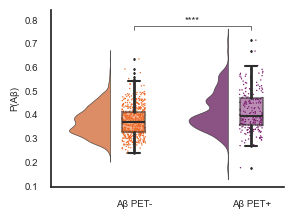

In [108]:
# profile_order = ['A-T-', 'A+T-', 'A+MTL+', 'A+NEO+']

# df_filtered = tau_reg[tau_reg['AT_ProfileReg'].isin(profile_order)]
import ptitprince1 as pt
custom_palette = ['#fca50a', '#6a176e']

font_sizes = 7
fig, ax = plt.subplots(figsize=(3, 2.3))

ax = pt.RainCloud(data = preclin, x = "amy_label_label", y = "amy_label_prob", orient='v', alpha=0.8,
palette = "inferno_r", bw=.2, ax=ax, linewidth=0.5, dodge=True, width_viol=.7, width_box=0.2, point_size = 1, jitter=1, cut =3)

pairs = [(0, 1)]
annotator = Annotator(ax, pairs, data=preclin, x='amy_label_label', y='amy_label_prob', order=[0, 1])

# Configure the statistical test and annotation
annotator.configure(
    test='Mann-Whitney',  # Changed from 't-test_ind' to 'Mann-Whitney'
    text_format='star',
    loc='inside',
    verbose=2,
    fontsize=7,
    line_width=0.5
)

annotator.apply_and_annotate()
plt.xlabel('')
plt.ylabel('P(Aβ)')
plt.xticks([0, 1], [f'Aβ PET-', f'Aβ PET+'], fontname='Arial', fontsize=font_sizes)

ax.set_xlabel("",  fontname='Arial', fontsize = font_sizes)
ax.set_ylabel("P(Aβ)", fontname='Arial', fontsize = font_sizes)
ax.tick_params(axis='both', labelsize=font_sizes)
current_xlim = ax.get_xlim()
ax.set_xlim(current_xlim[0] - 0.2, current_xlim[1])  # Add more space to the left

sns.despine()
plt.savefig('pdf_plots/fig3c.pdf',dpi=300, bbox_inches='tight')

# Fig 3d

In [86]:
df = pd.read_csv('data/fig3_all_data.csv')
df

,amy_label_label,tau_label_label,amy_label_prob,tau_label_prob,cdr_CDRGLOB,COHORT,tau_front_label_label,tau_occ_label_label,tau_medtemp_label_label,tau_lattemp_label_label,...,cd_NACCUDSD,amy_CENTILOIDS,tau_PARIETAL_SUVR,tau_META_VILLE_SUVR,tau_MEDIAL_TEMPORAL_SUVR,tau_LATERAL_TEMPORAL_SUVR,tau_MEDIAL_PARIETAL_SUVR,tau_LATERAL_PARIETAL_SUVR,tau_OCCIPITAL_SUVR,tau_FRONTAL_SUVR
0,0,0.0,0.410,0.403,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-15.0,NaN,1.105241,1.079772,1.062204,1.061575,0.981454,1.017863,0.989466
1,1,0.0,0.431,0.537,0.5,ADNI,0.0,0.0,0.0,0.0,...,3.0,61.0,NaN,1.225454,1.278876,1.150311,1.068291,1.072042,1.137212,1.096695
2,0,0.0,0.423,0.410,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,-9.0,NaN,1.210298,1.220804,1.128454,1.166971,1.024162,1.137282,1.125059
3,1,1.0,0.374,0.391,0.0,ADNI,0.0,0.0,1.0,0.0,...,0.0,46.0,NaN,1.410974,1.479579,1.248403,1.219296,1.072145,1.157214,1.206941
4,1,0.0,0.325,0.341,0.0,ADNI,0.0,0.0,0.0,0.0,...,0.0,130.0,NaN,1.168234,1.176571,1.103342,1.082553,1.023759,1.075810,1.073625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1828,1,NaN,0.435,0.572,2.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1829,0,NaN,0.624,0.773,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1830,1,NaN,0.547,0.724,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1831,1,NaN,0.555,0.742,1.0,NACC,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [88]:
df_tau = df.dropna(subset=['tau_medtemp_label_label'])
df_tau.shape

(799, 29)

In [89]:
probas = ['tau_medtemp_label_prob', 'tau_lattemp_label_prob', 'tau_medpar_label_prob', 'tau_latpar_label_prob', 'tau_occ_label_prob', 'tau_front_label_prob']
gts = ['tau_MEDIAL_TEMPORAL_SUVR', 'tau_LATERAL_TEMPORAL_SUVR', 'tau_MEDIAL_PARIETAL_SUVR', 'tau_LATERAL_PARIETAL_SUVR', 'tau_OCCIPITAL_SUVR', 'tau_FRONTAL_SUVR',]

In [91]:
conditions = [
    (df_tau['amy_label_label'] == 0) & (df_tau['tau_medtemp_label_label'] == 0) & (df_tau['tau_lattemp_label_label'] == 0) & (df_tau['tau_medpar_label_label'] == 0) & (df_tau['tau_latpar_label_label'] == 0) & (df_tau['tau_front_label_label'] == 0) & (df_tau['tau_occ_label_label'] == 0),
    (df_tau['amy_label_label'] == 1) & (df_tau['tau_medtemp_label_label'] == 0) & (df_tau['tau_lattemp_label_label'] == 0) & (df_tau['tau_medpar_label_label'] == 0) & (df_tau['tau_latpar_label_label'] == 0)  & (df_tau['tau_front_label_label'] == 0) & (df_tau['tau_occ_label_label'] == 0),
    (df_tau['amy_label_label'] == 1) & (df_tau['tau_medtemp_label_label'] == 1) & (df_tau['tau_lattemp_label_label'] == 0) & (df_tau['tau_medpar_label_label'] == 0) & (df_tau['tau_latpar_label_label'] == 0)  & (df_tau['tau_front_label_label'] == 0) & (df_tau['tau_occ_label_label'] == 0),
    (df_tau['amy_label_label'] == 1) & (df_tau['tau_medtemp_label_label'] == 1) & ((df_tau['tau_lattemp_label_label'] == 1) | (df_tau['tau_medpar_label_label'] == 1) | (df_tau['tau_latpar_label_label'] == 1) |  (df_tau['tau_front_label_label'] == 1) | (df_tau['tau_occ_label_label'] == 1))
]


choices = [
    'A-T-', 
    'A+T-',
    'A+MTL+',
    'A+NEO+'
]

df_tau['AT_ProfileReg'] = np.select(conditions, choices, default='Other')
df_tau['AT_ProfileReg'].value_counts()
tau_reg = df_tau[df_tau['AT_ProfileReg'] != 'Other']

/scratch/5475227.1.cbm.q/ipykernel_2699742/3036692553.py:16: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [93]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['amy_label_prob', 'tau_medtemp_label_prob', 
            'tau_lattemp_label_prob', 'tau_medpar_label_prob', 
            'tau_latpar_label_prob', 'tau_occ_label_prob', 'tau_front_label_prob']
X = tau_reg[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=1)
tau_reg['ATRegScore_PC1'] = pca.fit_transform(X_scaled).flatten()
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")

loadings = pd.DataFrame(pca.components_.T, index=features, columns=['PC1'])
print(loadings)

PC1 explains 97.5% of variance
                             PC1
amy_label_prob          0.356259
tau_medtemp_label_prob  0.381395
tau_lattemp_label_prob  0.381977
tau_medpar_label_prob   0.382021
tau_latpar_label_prob   0.382119
tau_occ_label_prob      0.381020
tau_front_label_prob    0.380236


/scratch/5475227.1.cbm.q/ipykernel_2699742/3950799835.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [97]:
levene_test(tau_reg, 'AT_ProfileReg', 'ATRegScore_PC1')

Normality test for group A-T-: Stat=0.8534125685691833, p-value=3.7399883137091756e-19
Normality test for group A+T-: Stat=0.8589514493942261, p-value=3.3964522860863156e-10
Normality test for group A+MTL+: Stat=0.9291375875473022, p-value=0.007052532397210598
Normality test for group A+NEO+: Stat=0.951030433177948, p-value=0.0009066092316061258
Levene’s test for equal variances: Stat=34.202901694686915, p-value=1.2645135631317484e-20


In [100]:
profile_order = ['A-T-', 'A+T-', 'A+MTL+', 'A+NEO+']

df_filtered = tau_reg[tau_reg['AT_ProfileReg'].isin(profile_order)]

res = kruskall_duns(df_filtered, 'AT_ProfileReg', 'ATRegScore_PC1')

Kruskal-Wallis result: Statistic=180.7265596797456, p-value=6.145548700287267e-39
              A+MTL+        A+NEO+          A+T-          A-T-
A+MTL+  1.000000e+00  4.961368e-03  2.992395e-03  8.973874e-09
A+NEO+  4.961368e-03  1.000000e+00  1.485717e-14  1.716271e-36
A+T-    2.992395e-03  1.485717e-14  1.000000e+00  2.629955e-04
A-T-    8.973874e-09  1.716271e-36  2.629955e-04  1.000000e+00


In [101]:
tau_reg['AT_ProfileReg'].value_counts()

AT_ProfileReg
A-T-      411
A+T-      139
A+NEO+    101
A+MTL+     47
Name: count, dtype: int64

In [102]:
def get_kruskal_dunn_pvalues(df, pairs):
    
    group_labels = sorted(list(set([value for pair in pairs for value in pair])))
    
    data = [
        list(df[df['AT_ProfileReg'] == cdr]['ATRegScore_PC1']) for cdr in group_labels
    ]
    
    for i in data:
        print(len(i))

    values = []
    for i, group_data in enumerate(data):
        values.extend([(value, group_labels[i]) for value in group_data])

    df_ = pd.DataFrame(values, columns=['Value', 'Group'])
    
    kw_result = stats.kruskal(*[group_data for label, group_data in df_.groupby('Group')['Value']])

    print("Kruskal-Wallis Test:")
    print(f"Statistically significant: {kw_result.pvalue < 0.05}", kw_result.pvalue)

    # post hoc pairwise- Dunn's
    posthoc_dunn = sp.posthoc_dunn(df_, val_col='Value', group_col='Group', p_adjust='holm')
    # print(posthoc_dunn)
    # print(posthoc_dunn[posthoc_dunn.columns[::-1]])
    posthoc_dunn = posthoc_dunn[posthoc_dunn.columns[::-1]]
    p_values = {val: dict(posthoc_dunn[val]) for val in group_labels}
    
    values = [p_values[i][j] for (i,j) in pairs]
    
    return posthoc_dunn, values
    # return values

In [103]:
ax1_pairs = [('A-T-', 'A+T-'), ('A+T-', 'A+MTL+'), ('A+MTL+', 'A+NEO+'), ('A-T-', 'A+NEO+'), ('A-T-', 'A+MTL+'), ('A+T-', 'A+NEO+')]
print(get_kruskal_dunn_pvalues(df_filtered, ax1_pairs))

47
101
139
411
Kruskal-Wallis Test:
Statistically significant: True 6.145548700287267e-39
(                A-T-          A+T-        A+NEO+        A+MTL+
A+MTL+  8.973874e-09  2.992395e-03  4.961368e-03  1.000000e+00
A+NEO+  1.716271e-36  1.485717e-14  1.000000e+00  4.961368e-03
A+T-    2.629955e-04  1.000000e+00  1.485717e-14  2.992395e-03
A-T-    1.000000e+00  2.629955e-04  1.716271e-36  8.973874e-09, [0.000262995512333889, 0.002992395419009287, 0.0049613678972963305, 1.7162706378119628e-36, 8.973874273202809e-09, 1.4857171744955893e-14])


In [104]:
def map_values(value):
    if isinstance(value, str):
        return value
    if value < 0.0001:
        return '****        '
    elif value < 0.001:
        return '***       '
    elif value < 0.01:
        return '**         '
    elif value < 0.05:
        return '    *     '
    elif value <= 1.0:
        return 'ns'
    else:
        return str(value)
    
def get_annotate_matrix(matrix_content):
    print(matrix_content)
    row_indices = matrix_content.index
    column_indices = matrix_content.columns

    matrix_content_values = np.vectorize(map_values)(matrix_content.values)
    # print(matrix_content_values)

    matrix_with_indices = np.column_stack((matrix_content_values, row_indices))
    column_indices = np.insert(column_indices.values, 0, '', axis=0)
    matrix_with_indices = np.row_stack((matrix_with_indices, column_indices))
    print("matrix_with_indices", matrix_with_indices)
    main = []
    # main.append('p-values              ')
    for i, row in enumerate(matrix_with_indices):
        if i == len(matrix_with_indices) - 1:
            row = row[2:]
        elif i == 0:
            row = row[len(row) - i:]
        else:
            row = row[len(row) - i - 1:]
        cr = []
        for cell in row:
            cr.append('{: <5}'.format(str(cell)))
        main.append('  '.join(cr))
        
    main[-1] = main[-1] + "              "
    main = main[1:]
    return main

def annotate(df, ax, pairs, order, xy=(0.95, 0.03)):
    annot = Annotator(ax, pairs=pairs, data=df, x='AT_ProfileReg', y='ATRegScore_PC1', order=order)
    matrix_content, _ = get_kruskal_dunn_pvalues(df, pairs=pairs)
    matrix_text = get_annotate_matrix(matrix_content)
    
    matrix_text.insert(0, 'p-values{: <20}'.format(' '))
    # matrix_text.insert(0, 'p-values{: <5}'.format(' '))
    matrix_text = '\n'.join(matrix_text)
    print(matrix_text)
    ax.annotate(matrix_text, xy=xy, xycoords='axes fraction', ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor=(1, 1, 1, 0.0)))

In [111]:
tau_reg[['AT_ProfileReg', 'ATRegScore_PC1']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/fig3d.csv', index=False)

47
101
139
411
Kruskal-Wallis Test:
Statistically significant: True 6.145548700287267e-39
                A-T-          A+T-        A+NEO+        A+MTL+
A+MTL+  8.973874e-09  2.992395e-03  4.961368e-03  1.000000e+00
A+NEO+  1.716271e-36  1.485717e-14  1.000000e+00  4.961368e-03
A+T-    2.629955e-04  1.000000e+00  1.485717e-14  2.992395e-03
A-T-    1.000000e+00  2.629955e-04  1.716271e-36  8.973874e-09
matrix_with_indices [['****        ' '**         ' '**         ' 'ns' 'A+MTL+']
 ['****        ' '****        ' 'ns' '**         ' 'A+NEO+']
 ['***       ' 'ns' '****        ' '**         ' 'A+T-']
 ['ns' '***       ' '****        ' '****        ' 'A-T-']
 ['' 'A-T-' 'A+T-' 'A+NEO+' 'A+MTL+']]
p-values                    
**           A+NEO+
****          **           A+T- 
***         ****          ****          A-T- 
A+T-   A+NEO+  A+MTL+              


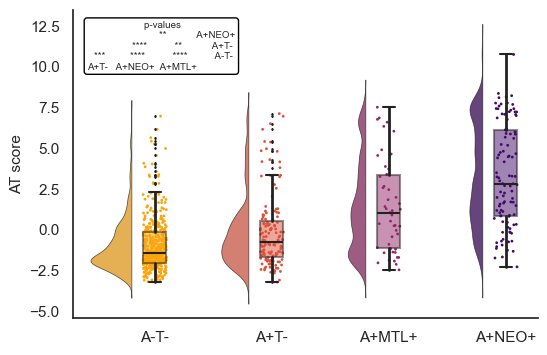

In [109]:
profile_order = ['A-T-', 'A+T-', 'A+MTL+', 'A+NEO+']

df_filtered = tau_reg[tau_reg['AT_ProfileReg'].isin(profile_order)]


font_sizes = 11
fig, ax = plt.subplots(figsize=(6,4))

ax = pt.RainCloud(data = df_filtered, x = "AT_ProfileReg", y = "ATRegScore_PC1", orient='v', alpha=0.8,
palette = "inferno_r", bw=.2, ax=ax, linewidth=0.5, dodge=True, width_viol=.7, width_box=0.2, point_size = 2, jitter=1, cut =3)

annotate(df=df_filtered, ax=ax, pairs=ax1_pairs, order=profile_order, xy=(0.35, 0.80))

plt.xlabel('')
plt.ylabel('AT score')
ax.set_xlabel("",  fontname='Arial', fontsize = font_sizes)
ax.set_ylabel("AT score", fontname='Arial', fontsize = font_sizes)
ax.tick_params(axis='both', labelsize=font_sizes)
current_xlim = ax.get_xlim()
ax.set_xlim(current_xlim[0] - 0.2, current_xlim[1])  # Add more space to the left

sns.despine()
plt.savefig('pdf_plots/fig3d.pdf',dpi=300, bbox_inches='tight')


# Regional tau labels - Extended Figure 4

## medtemp

In [67]:
adas_data_tau[['tau_medtemp_label_prob', 'tau_MEDIAL_TEMPORAL_SUVR', 'bat_TOTAL13']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/efig4a.csv', index=False)

In [57]:
bubble_plot_tau(adas_data_tau, 'tau_medtemp_label_prob', 'tau_MEDIAL_TEMPORAL_SUVR', 'P(med-temp τ)', 'med-temp τ SUVr', 'EF4a')

Spearman's correlation: 0.44, P-value: 4.52e-31
Pearson's correlation coefficient: 0.56, P-value: 1.14e-52


## lattemp

In [68]:
adas_data_tau[['tau_lattemp_label_prob', 'tau_LATERAL_TEMPORAL_SUVR', 'bat_TOTAL13']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/efig4b.csv', index=False)

In [58]:
bubble_plot_tau(adas_data_tau, 'tau_lattemp_label_prob', 'tau_LATERAL_TEMPORAL_SUVR', 'P(lat-temp τ)', 'lat-temp τ SUVr', 'EF4b')

Spearman's correlation: 0.37, P-value: 2.63e-21
Pearson's correlation coefficient: 0.52, P-value: 1.86e-43


## medpar

In [69]:
adas_data_tau[['tau_medpar_label_prob', 'tau_MEDIAL_PARIETAL_SUVR', 'bat_TOTAL13']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/efig4c.csv', index=False)

In [59]:
bubble_plot_tau(adas_data_tau, 'tau_medpar_label_prob', 'tau_MEDIAL_PARIETAL_SUVR', 'P(med-par τ)', 'med-par τ SUVr', 'EF4c')

Spearman's correlation: 0.28, P-value: 1.01e-12
Pearson's correlation coefficient: 0.44, P-value: 2.35e-31


## latpar

In [70]:
adas_data_tau[['tau_latpar_label_prob', 'tau_LATERAL_PARIETAL_SUVR', 'bat_TOTAL13']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/efig4d.csv', index=False)

In [60]:
bubble_plot_tau(adas_data_tau, 'tau_latpar_label_prob', 'tau_LATERAL_PARIETAL_SUVR', 'P(lat-par τ)', 'lat-par τ SUVr', 'EF4d')

Spearman's correlation: 0.29, P-value: 1.16e-13
Pearson's correlation coefficient: 0.45, P-value: 1.54e-32


## frontal

In [71]:
adas_data_tau[['tau_front_label_prob', 'tau_FRONTAL_SUVR', 'bat_TOTAL13']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/efig4e.csv', index=False)

In [61]:
bubble_plot_tau(adas_data_tau, 'tau_front_label_prob', 'tau_FRONTAL_SUVR', 'P(frt τ)', 'frt τ SUVr', 'EF4e')

Spearman's correlation: 0.20, P-value: 4.78e-07
Pearson's correlation coefficient: 0.35, P-value: 3.74e-19


## Occipital

In [72]:
adas_data_tau[['tau_occ_label_prob', 'tau_OCCIPITAL_SUVR', 'bat_TOTAL13']].to_csv('/projectnb/vkolagrp/varuna/ncomms2025/figures/source_data/efig4f.csv', index=False)

In [62]:
bubble_plot_tau(adas_data_tau, 'tau_occ_label_prob', 'tau_OCCIPITAL_SUVR', 'P(occ τ)', 'occ τ SUVr', 'EF4f')

Spearman's correlation: 0.28, P-value: 2.74e-12
Pearson's correlation coefficient: 0.40, P-value: 1.68e-25


In [63]:
spear_correlation_medtemp, p_value_medtemp_rho = spearmanr(adas_data_tau["tau_medtemp_label_prob"], np.log(adas_data_tau["tau_MEDIAL_TEMPORAL_SUVR"]))
pear_correlation_medtemp, p_value_medtemp_pear = pearsonr(adas_data_tau["tau_medtemp_label_prob"], np.log(adas_data_tau["tau_MEDIAL_TEMPORAL_SUVR"]))

spear_correlation_lattemp, p_value_lattemp_rho = spearmanr(adas_data_tau["tau_lattemp_label_prob"], np.log(adas_data_tau["tau_LATERAL_TEMPORAL_SUVR"]))
pear_correlation_lattemp, p_value_lattemp_pear = pearsonr(adas_data_tau["tau_lattemp_label_prob"], np.log(adas_data_tau["tau_LATERAL_TEMPORAL_SUVR"]))

spear_correlation_medpar, p_value_medpar_rho = spearmanr(adas_data_tau["tau_medpar_label_prob"], np.log(adas_data_tau["tau_MEDIAL_PARIETAL_SUVR"]))
pear_correlation_medpar, p_value_medpar_pear = pearsonr(adas_data_tau["tau_medpar_label_prob"], np.log(adas_data_tau["tau_MEDIAL_PARIETAL_SUVR"]))

spear_correlation_latpar, p_value_latpar_rho = spearmanr(adas_data_tau["tau_latpar_label_prob"], np.log(adas_data_tau["tau_LATERAL_PARIETAL_SUVR"]))
pear_correlation_latpar, p_value_latpar_pear = pearsonr(adas_data_tau["tau_latpar_label_prob"], np.log(adas_data_tau["tau_LATERAL_PARIETAL_SUVR"]))

spear_correlation_front, p_value_front_rho = spearmanr(adas_data_tau["tau_front_label_prob"], np.log(adas_data_tau["tau_FRONTAL_SUVR"]))
pear_correlation_front, p_value_front_pear = pearsonr(adas_data_tau["tau_front_label_prob"], np.log(adas_data_tau["tau_FRONTAL_SUVR"]))

spear_correlation_occ, p_value_occ_rho = spearmanr(adas_data_tau["tau_occ_label_prob"], np.log(adas_data_tau["tau_OCCIPITAL_SUVR"]))
pear_correlation_occ, p_value_occ_pear = pearsonr(adas_data_tau["tau_occ_label_prob"], np.log(adas_data_tau["tau_OCCIPITAL_SUVR"]))

regions = ['Medial temporal', 'Lateral temporal', 'Medial parietal', 'Lateral parietal', 'Frontal ', 'Occipital']

pearson_corr = [pear_correlation_medtemp, pear_correlation_lattemp, pear_correlation_medpar, 
                pear_correlation_latpar, pear_correlation_front, pear_correlation_occ]
pearson_pvals = [p_value_medtemp_pear, p_value_lattemp_pear, p_value_medpar_pear, 
                p_value_latpar_pear, p_value_front_pear, p_value_occ_pear]
spearman_corr = [spear_correlation_medtemp, spear_correlation_lattemp, spear_correlation_medpar, 
                spear_correlation_lattemp, spear_correlation_front, spear_correlation_occ]
spearman_pvals = [p_value_medtemp_rho, p_value_lattemp_rho, p_value_medpar_rho, 
                 p_value_latpar_rho, p_value_front_rho, p_value_occ_rho]

def format_pvalue_latex(p_value):
    if p_value < 0.001:
        
        p_str = f"{p_value:.2e}"
        
        match = re.match(r'(\d+\.\d+)e([+-])(\d+)', p_str)
        if match:
            base, sign, exponent = match.groups()
            
            exponent = exponent.lstrip('0')
            if sign == '-':
                return f"{float(base):.2f} \\times 10^{{{sign}{exponent}}}"
            else:
                return f"{float(base):.2f} \\times 10^{{{exponent}}}"
    else:
        return f"{p_value:.3f}"

data = []
for i, region in enumerate(regions):
    # pearson correlation row
    data.append({
        'Label': region,
        'Coefficient': "r",
        'Correlation': f"{pearson_corr[i]:.2f}",
        'p-value': format_pvalue_latex(pearson_pvals[i])
    })
    # spearman correlation row
    data.append({
        'Label': region,
        'Coefficient': "ρ",
        'Correlation': f"{spearman_corr[i]:.2f}",
        'p-value': format_pvalue_latex(spearman_pvals[i])
    })

df = pd.DataFrame(data)

print(df)

latex_table = df.to_latex(index=False, escape=False)
print("\nLaTeX Table:")
print(latex_table)

               Label Coefficient Correlation               p-value
0    Medial temporal           r        0.56  1.14 \times 10^{-52}
1    Medial temporal           ρ        0.44  4.52 \times 10^{-31}
2   Lateral temporal           r        0.52  1.86 \times 10^{-43}
3   Lateral temporal           ρ        0.37  2.63 \times 10^{-21}
4    Medial parietal           r        0.44  2.35 \times 10^{-31}
5    Medial parietal           ρ        0.28  1.01 \times 10^{-12}
6   Lateral parietal           r        0.45  1.54 \times 10^{-32}
7   Lateral parietal           ρ        0.37  1.16 \times 10^{-13}
8           Frontal            r        0.35  3.74 \times 10^{-19}
9           Frontal            ρ        0.20   4.78 \times 10^{-7}
10         Occipital           r        0.40  1.68 \times 10^{-25}
11         Occipital           ρ        0.28  2.74 \times 10^{-12}

LaTeX Table:
\begin{tabular}{llll}
\toprule
Label & Coefficient & Correlation & p-value \\
\midrule
Medial temporal & r & 0.56 &